<a href="https://colab.research.google.com/github/bobo33772-blip/AI_study/blob/main/%EB%94%A5%EB%9F%AC%EB%8B%9D_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import keras
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(
    num_words=500)

In [13]:
print('x_train', x_train.shape)
print('y_train', y_train.shape)
print('x_test', x_test.shape)
print('y_test', y_test.shape)

x_train (25000,)
y_train (25000,)
x_test (25000,)
y_test (25000,)


In [14]:
# 리뷰. 자주사용된 500개단어
print(x_train[0])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]


In [15]:
# 리뷰 문장의 길이(문장의 단어수)
import numpy as np
lengths = np.array([ len(x) for x in x_train])
print('평균 문장 길이',sum(lengths)/len(lengths))
print('최대 문장 길이',max(lengths))
print('최소 문장 길이',min(lengths))

평균 문장 길이 238.71364
최대 문장 길이 2494
최소 문장 길이 11


In [16]:
# train test로 데이터 나누기
from sklearn.model_selection import train_test_split
train_input, val_input, train_target, val_target = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [25]:
# 리뷰 문장의 길이는 100단어크기로 일괄 변경하기
from keras.preprocessing.sequence import pad_sequences
train_seq = pad_sequences(train_input, maxlen=100)
val_seq = pad_sequences(val_input, maxlen=100)
# x_test = pad_sequences(x_test, maxlen=100)

In [26]:
# 나눈 데이터 길이 확인
print('train_input', train_input.shape)
print('val_input', val_input.shape)
print('train_target', train_target.shape)
print('val_target', val_target.shape)

train_input (20000,)
val_input (5000,)
train_target (20000,)
val_target (5000,)


In [27]:
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,)))
model.add(keras.layers.Embedding(500,16))
model.add(keras.layers.SimpleRNN(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
cp_cb = keras.callbacks.ModelCheckpoint(
    'best-embedding-model.keras',
    save_best_only=True)
es_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True)
history = model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[cp_cb, es_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 45ms/step - accuracy: 0.7010 - loss: 0.5750 - val_accuracy: 0.7638 - val_loss: 0.5040
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7688 - loss: 0.4946 - val_accuracy: 0.7416 - val_loss: 0.5287
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.7886 - loss: 0.4633 - val_accuracy: 0.7696 - val_loss: 0.4853
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.7907 - loss: 0.4570 - val_accuracy: 0.7758 - val_loss: 0.4741
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.8044 - loss: 0.4346 - val_accuracy: 0.7794 - val_loss: 0.4684
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.8123 - loss: 0.4194 - val_accuracy: 0.7914 - val_loss: 0.4611
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8106 - loss: 0.4209 - val_accuracy: 0.7804 - val_loss: 0.4675
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8225 - loss: 0

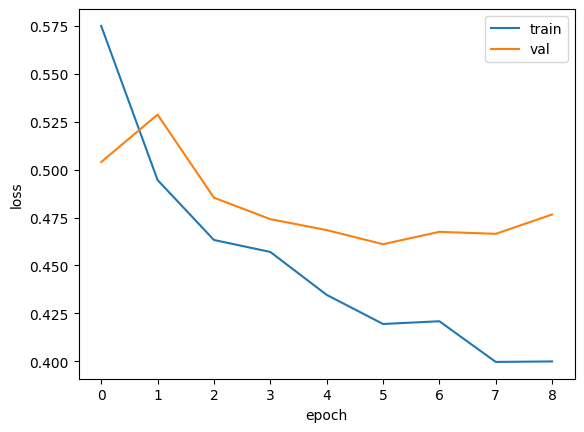

In [30]:
# loss 그리기
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])

In [31]:
whos

Variable           Type               Data/Info
-----------------------------------------------
cp_cb              ModelCheckpoint    <keras.src.callbacks.mode<...>object at 0x7f12c1f4fd10>
es_cb              EarlyStopping      <keras.src.callbacks.earl<...>object at 0x7f12bb5a1d60>
history            History            <keras.src.callbacks.hist<...>object at 0x7f12c1f4daf0>
keras              module             <module 'keras' from '/us<...>kages/keras/__init__.py'>
lengths            ndarray            25000: 25000 elems, type `int64`, 200000 bytes (195.3125 kb)
model              Sequential         <Sequential name=sequential_3, built=True>
np                 module             <module 'numpy' from '/us<...>kages/numpy/__init__.py'>
pad_sequences      function           <function pad_sequences at 0x7f12f695f560>
plt                module             <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
train_input        ndarray            20000: 20000 elems, type `object`, 160000

In [32]:
# LSTM 적용
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,)))
model.add(keras.layers.Embedding(500,16))
model.add(keras.layers.LSTM(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
cp_cb = keras.callbacks.ModelCheckpoint(
    'best-embedding-model.keras',
    save_best_only=True)
es_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True)
history = model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[cp_cb, es_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.6984 - loss: 0.5793 - val_accuracy: 0.7788 - val_loss: 0.4872
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.7873 - loss: 0.4645 - val_accuracy: 0.7670 - val_loss: 0.4835
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8016 - loss: 0.4329 - val_accuracy: 0.7834 - val_loss: 0.4577
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.8051 - loss: 0.4256 - val_accuracy: 0.7994 - val_loss: 0.4327
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.8110 - loss: 0.4114 - val_accuracy: 0.8044 - val_loss: 0.4245
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 43ms/step - accuracy: 0.8198 - loss: 0.3981 - val_accuracy: 0.8056 - val_loss: 0.4225
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.8221 - loss: 0.3928 - val_accuracy: 0.8102 - val_loss: 0.4187
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.8259 - loss: 0

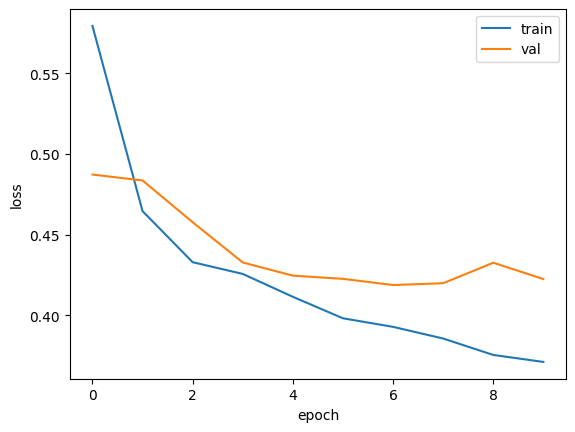

In [33]:
# loss 그리기
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])

In [34]:
# GRU적용
model = keras.Sequential()
model.add(keras.layers.Input(shape=(100,)))
model.add(keras.layers.Embedding(500,16))
model.add(keras.layers.GRU(8))
model.add(keras.layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'])
cp_cb = keras.callbacks.ModelCheckpoint(
    'best-embedding-model.keras',
    save_best_only=True)
es_cb = keras.callbacks.EarlyStopping(
    patience=3,
    restore_best_weights=True)
history = model.fit(
    train_seq,
    train_target,
    epochs=100,
    batch_size=64,
    validation_data=(val_seq, val_target),
    callbacks=[cp_cb, es_cb]
)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 62ms/step - accuracy: 0.6518 - loss: 0.6093 - val_accuracy: 0.7490 - val_loss: 0.5235
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.7749 - loss: 0.4838 - val_accuracy: 0.7804 - val_loss: 0.4698
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.7837 - loss: 0.4658 - val_accuracy: 0.7874 - val_loss: 0.4581
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.7976 - loss: 0.4458 - val_accuracy: 0.7906 - val_loss: 0.4501
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 52ms/step - accuracy: 0.8034 - loss: 0.4355 - val_accuracy: 0.8018 - val_loss: 0.4345
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 56ms/step - accuracy: 0.8105 - loss: 0.4210 - val_accuracy: 0.8012 - val_loss: 0.4308
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.8137 - loss: 0.4119 - val_accuracy: 0.7894 - val_loss: 0.4491
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - accuracy: 0.8156 - loss: 0

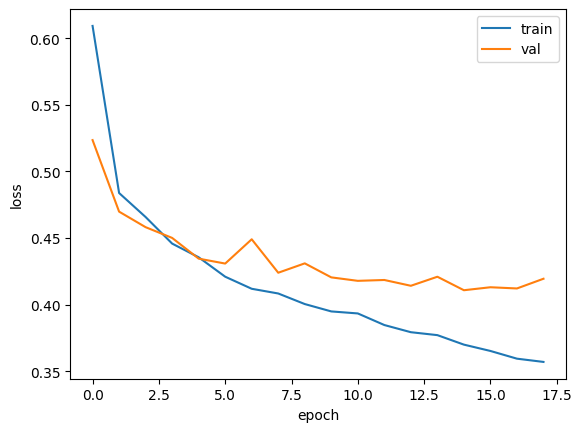

In [35]:
# loss 그리기
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','val'])